In [12]:
import pandas as pd

In [13]:
df = pd.read_csv("store_data.csv")

In [14]:
# Convert sales to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

## Monthly Sales Trend

In [15]:
# Ensure order_date is converted to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format="%d-%m-%Y")

# Now group by month
monthly_sales = (
    df.groupby(df['order_date'].dt.month)['sales']
    .sum()
)

# Convert index to string if needed
monthly_sales.index = monthly_sales.index.astype(str)

print(monthly_sales.head())

order_date
1    385781.0
2    339990.0
3    466475.0
4    455594.0
5    562178.0
Name: sales, dtype: float64


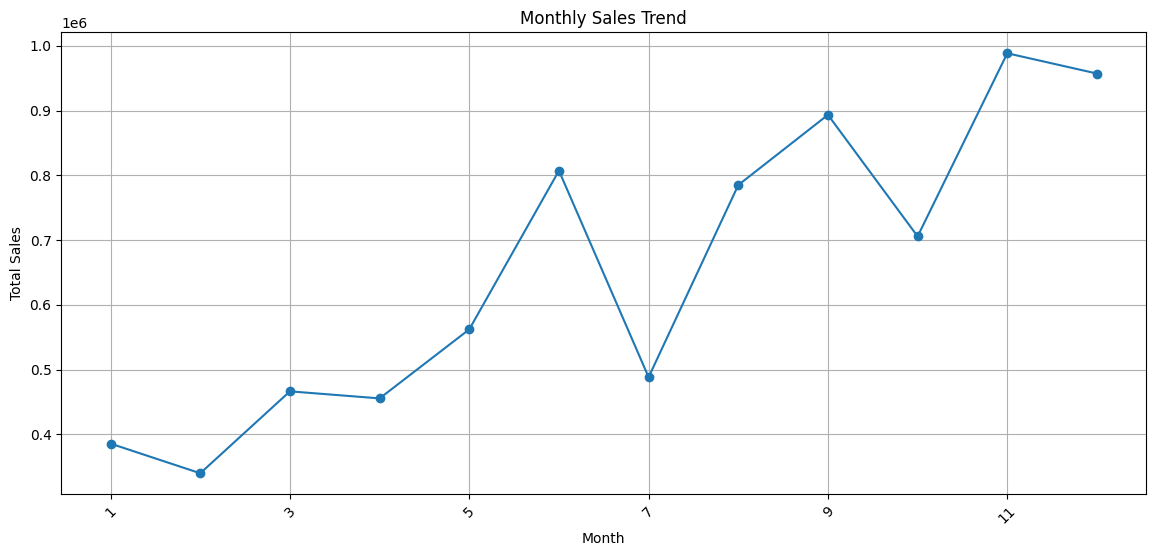

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [6]:
%uv add seaborn

Note: you may need to restart the kernel to use updated packages.


Resolved 46 packages in 4ms
Checked 40 packages in 13ms


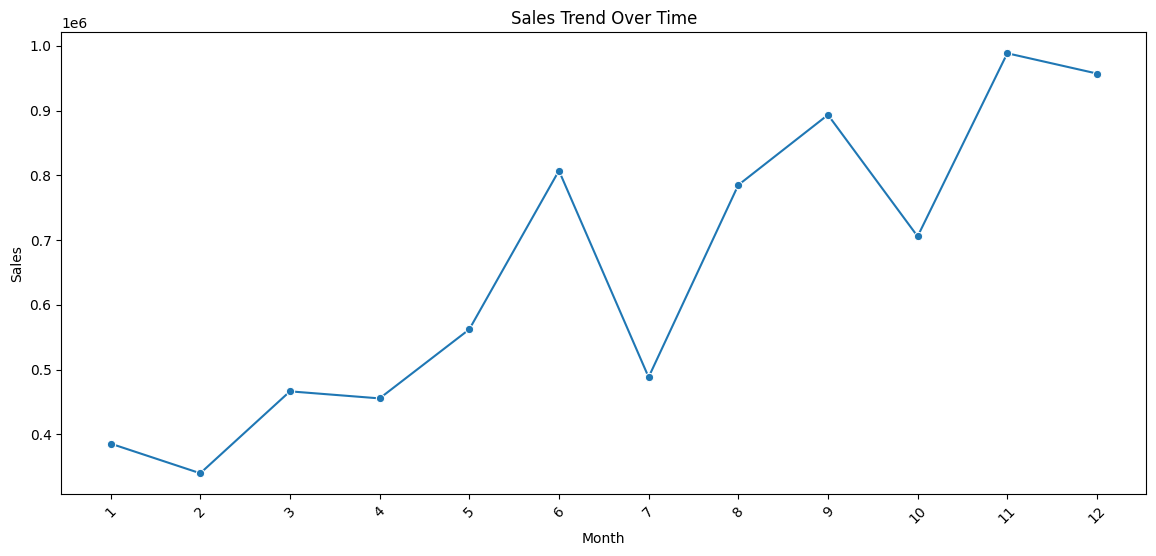

In [7]:
import seaborn as sns

monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Month', 'Sales']

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales_df,
    x='Month',
    y='Sales',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Sales Trend Over Time')
plt.show()

## Regional Performance

In [17]:
regional_performance = (
    df.groupby('region')
    .agg({
        'sales': 'sum',
        'profit': 'sum',
        'quantity': 'sum',
        'shipping_cost': 'sum',
        'order_id': 'count'
    })
    .rename(columns={'order_id': 'total_orders'})
)

regional_performance['profit_margin'] = (
    regional_performance['profit'] /
    regional_performance['sales']
) * 100

regional_performance['avg_order_value'] = (
    regional_performance['sales'] /
    regional_performance['total_orders']
)

regional_performance = regional_performance.sort_values(
    by='sales',
    ascending=False
)

regional_performance

,sales,profit,quantity,shipping_cost,total_orders,profit_margin,avg_order_value
region,,,,,,,
Central,1806638.0,311403.98164,41762,296940.56,11117,17.236656,162.511289
South,1031101.0,140355.76618,25206,168474.07,6645,13.612223,155.169451
North,790546.0,194597.95252,18021,131474.09,4785,24.615639,165.213375
Oceania,625382.0,121666.64200,12838,120628.51,3487,19.454772,179.346716
EMEA,575562.0,43897.97100,11517,88375.73,5029,7.626975,114.448598
Africa,538115.0,88871.63100,10564,88139.47,4587,16.515360,117.313059
Southeast Asia,532172.0,17852.32900,11822,93675.84,3129,3.354616,170.077341
North Asia,453686.0,165578.42100,8851,95030.61,2338,36.496260,194.048760
West,424173.0,108418.44890,12266,76512.26,3203,25.559960,132.429909


## Visualization — Profit margin by Region

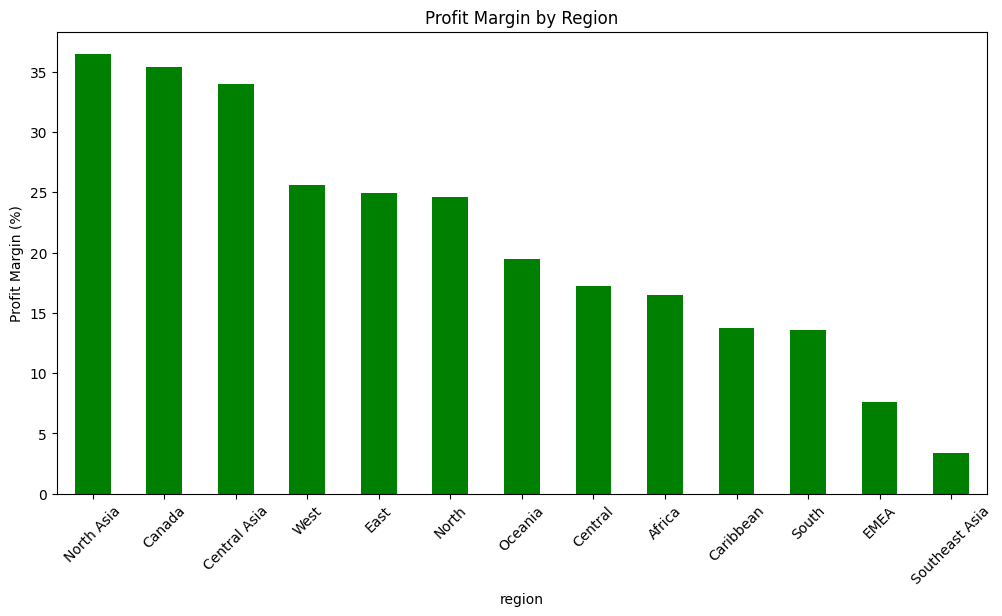

In [9]:
profit_margin = (
    regional_performance['profit_margin']
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

profit_margin.plot(
    kind='bar',
    color='green'
)

plt.title('Profit Margin by Region')
plt.ylabel('Profit Margin (%)')

plt.xticks(rotation=45)
plt.show()

## Visualization — Top 10 Products by Revenue

C:\Users\venkataprasadk\AppData\Local\Temp\ipykernel_20760\4158395896.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


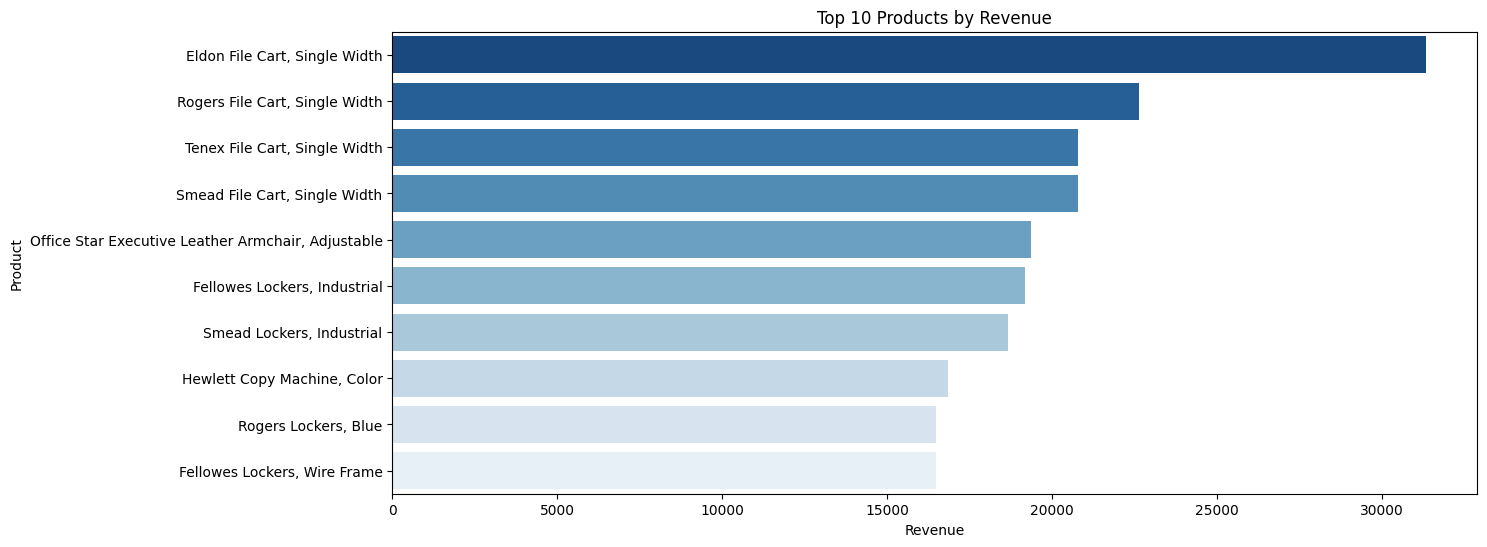

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_sales = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top10_sales.values,
    y=top10_sales.index,
    palette='Blues_r'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

## Visualization — Top 10 Products by Profit

C:\Users\venkataprasadk\AppData\Local\Temp\ipykernel_20760\3073899229.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


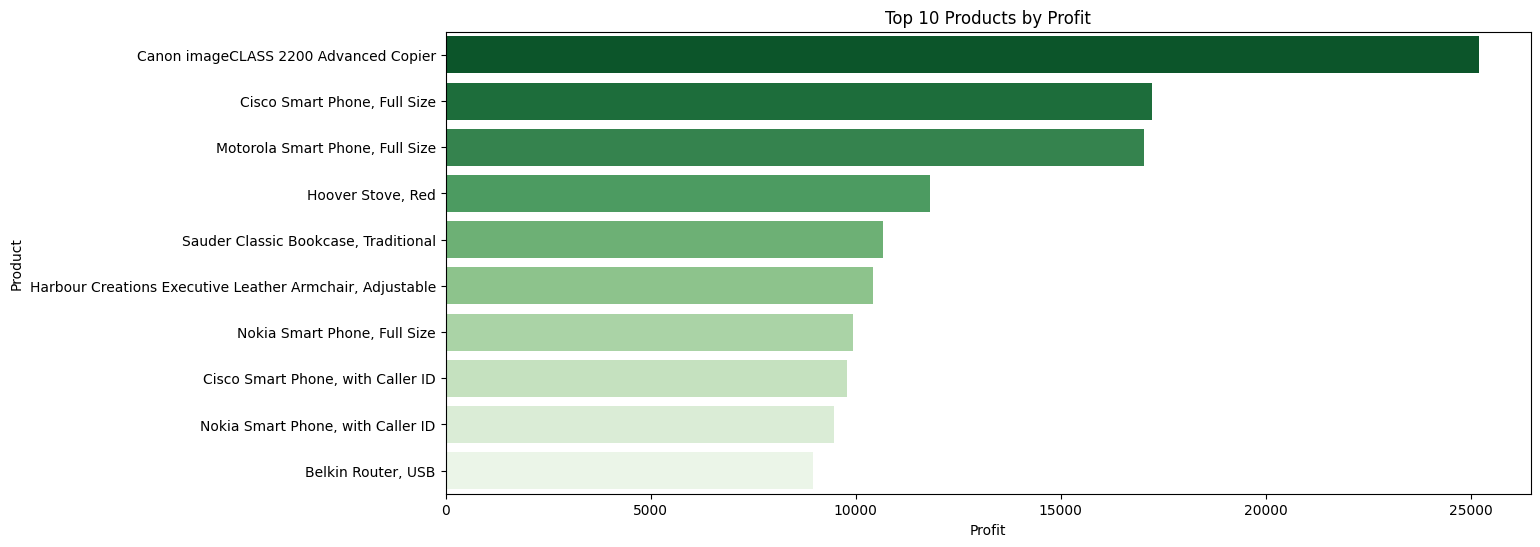

In [11]:
top10_profit = (
    df.groupby('product_name')['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top10_profit.values,
    y=top10_profit.index,
    palette='Greens_r'
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()